In [1]:
import os
import sys
import pyarrow as pa
from pathlib import Path
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from tqdm import tqdm
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
sys.path.insert(0, "..")
from paths import resolve

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
_NCPU = os.cpu_count() or 1
pa.set_cpu_count(_NCPU)
pa.set_io_thread_count(_NCPU)
os.environ["NUMEXPR_MAX_THREADS"] = str(_NCPU)
os.environ["NUMEXPR_NUM_THREADS"] = str(_NCPU)
os.environ.setdefault("OMP_NUM_THREADS", str(_NCPU))
os.environ.setdefault("OPENBLAS_NUM_THREADS", str(_NCPU))
os.environ.setdefault("MKL_NUM_THREADS", str(_NCPU))
print(f"Running with {_NCPU} CPU cores | pyarrow {pa.__version__}", flush=True)

Running with 48 CPU cores | pyarrow 24.0.0


Variables

In [2]:
%run ../0_Config/0_variables.ipynb

Feature selection output

In [3]:
_stem = Path(os.environ['FEATURE_DATASET']).stem
_target = os.environ['TARGET']
horizon_best_k = pd.read_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_horizon_best_k_{_stem}.parquet")
)

_stem = Path(os.environ['FEATURE_DATASET']).stem
_target = os.environ['TARGET']
feature_data_unique = pd.read_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_feature_data_unique_{_stem}.parquet")
)

_stem = Path(os.environ['FEATURE_DATASET']).stem
_target = os.environ['TARGET']
gain_matrix_df = pd.read_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_gain_matrix_{_stem}.parquet")
)

def feature_selection_output(horizon_best_k, feature_data_unique, gain_matrix_df):
    horizon_cols = [c for c in feature_data_unique.columns if c.startswith("h") and c[1:].isdigit()]
    mi_matrix = feature_data_unique.set_index("feature")[horizon_cols]  # (n_features, n_horizons)
    gain_matrix = gain_matrix_df.set_index("feature")

    # For each evaluated horizon, select the top-best_k features by LightGBM gain (from stage 5).
    # Falls back to MI ranking when a horizon's gain column is missing or all-NaN
    # (e.g. horizon was not evaluated by CV / subsampled out).
    selection = pd.DataFrame(False, index=mi_matrix.index, columns=horizon_cols)

    n_fallback = 0
    for _, row in horizon_best_k.iterrows():
        h = row["horizon"]
        k = int(row["best_k"])
        if h not in mi_matrix.columns:
            continue
        if h in gain_matrix.columns and gain_matrix[h].notna().any():
            ranked = gain_matrix[h].dropna().sort_values(ascending=False)
            top_k_features = ranked.head(k).index
        else:
            top_k_features = mi_matrix[h].nlargest(k).index
            n_fallback += 1
        keep = [f for f in top_k_features if f in selection.index]
        selection.loc[keep, h] = True

    n_any = selection.any(axis=1).sum()
    print(
        f"Selected features per horizon (gain-ranked) | "
        f"features in any horizon: {n_any} of {len(mi_matrix)} | "
        f"per-horizon range: {selection.sum().min()}–{selection.sum().max()} | "
        f"fallback to MI for {n_fallback} horizons",
        flush=True,
    )

    selection.to_parquet(os.environ["selected_features_output"])
    display(selection[:3])

feature_selection_output(horizon_best_k, feature_data_unique, gain_matrix_df)


Selected features per horizon (gain-ranked) | features in any horizon: 85 of 440 | per-horizon range: 10–54 | fallback to MI for 0 horizons


,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,h25,h26,h27,h28,h29,h30,h31,h32,h33,h34,h35,h36,h37,h38,h39,h40,h41,h42,h43,h44,h45,h46,h47,h48,h49,h50,h51,h52,h53,h54,h55,h56,h57,h58,h59,h60,h61,h62,h63,h64,h65,h66,h67,h68,h69,h70,h71,h72,h73,h74,h75,h76,h77,h78,h79,h80,h81,h82,h83,h84,h85,h86,h87,h88,h89,h90,h91,h92,h93,h94,h95,h96
feature,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
nsw_price_q90_336,False,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
qld_price_q90_336,False,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
nsw_price_q10_336,False,False,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


Running with 47 CPU cores | 92.3GB total RAM (74.9GB available) | pyarrow 24.0.0
Loading [selected] /home/ec2-user/Forecasting/3_Features_select/../3_Features_select/Selected_features/NSW_selected_features_1_dispatch_price.parquet
  loaded selected: shape=(440, 96) in 0.0s


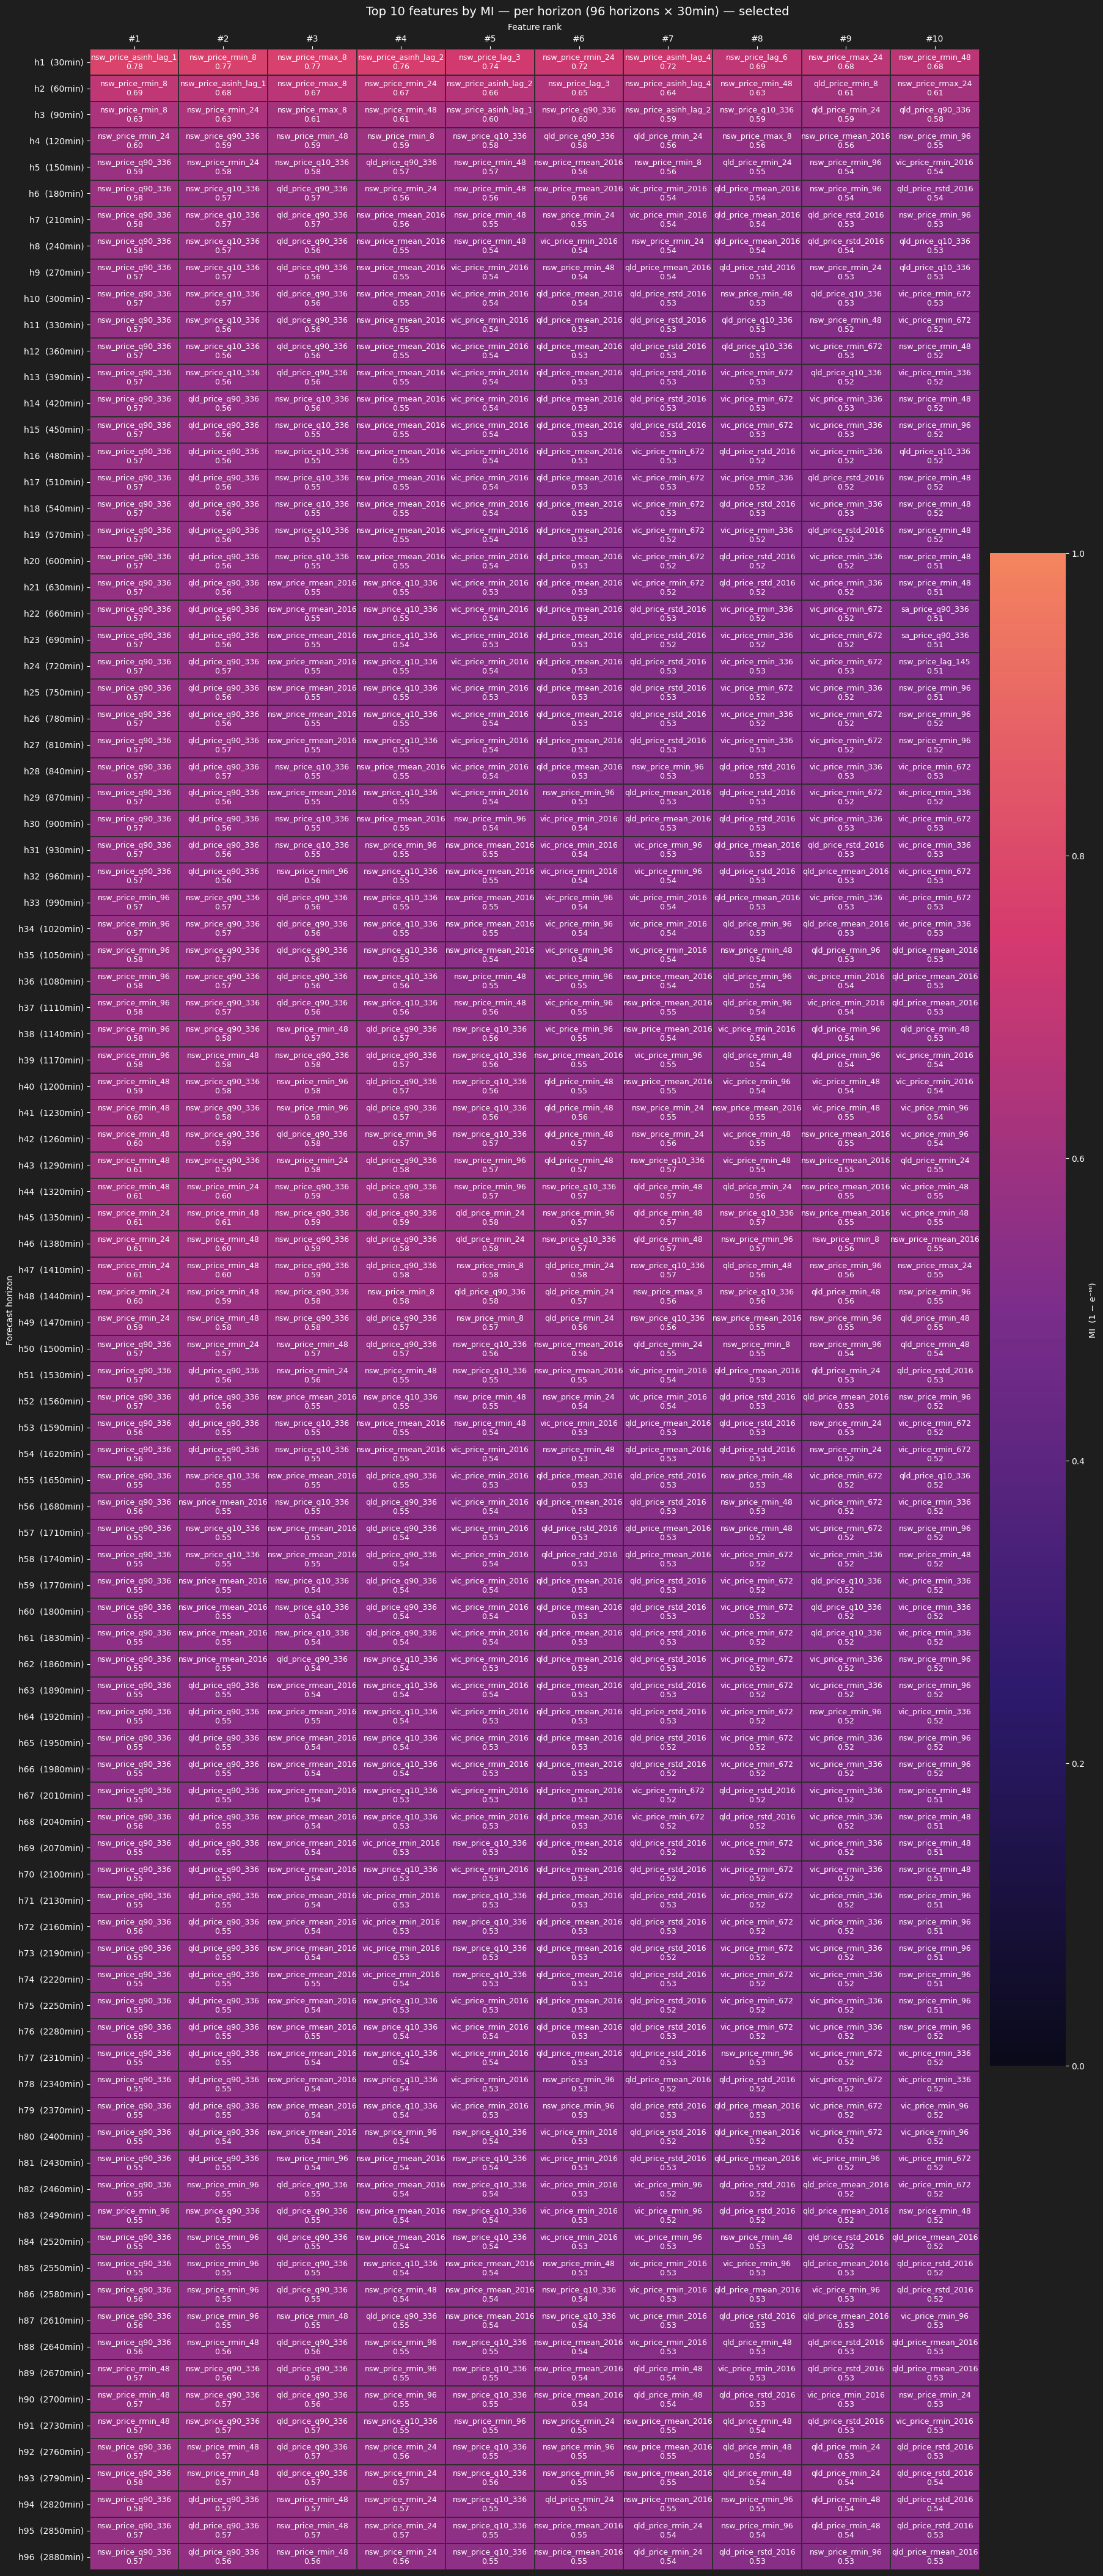

In [4]:
# Correlation matrix helper (auto-detects source if omitted)
%run 0_correlation_matrix.ipynb
plot_mi_top_features(source="selected", top_n=10)

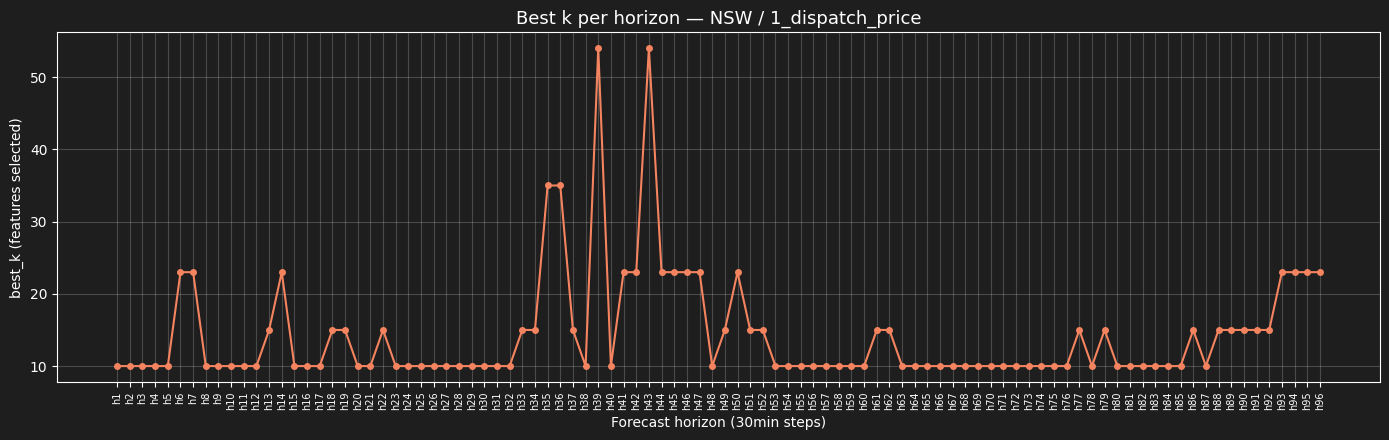

In [5]:
# Best-k per horizon
_OUTPUT_RESOLUTION = int(os.environ["OUTPUT_RESOLUTION"])
_hbk_plot = horizon_best_k.copy()
_hbk_plot["h_idx"] = _hbk_plot["horizon"].str[1:].astype(int)
_hbk_plot = _hbk_plot.sort_values("h_idx")
_hbk_plot["minutes_ahead"] = _hbk_plot["h_idx"] * _OUTPUT_RESOLUTION

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(14, 4.5))
    fig.patch.set_facecolor("#1e1e1e")
    ax.set_facecolor("#1e1e1e")
    ax.plot(_hbk_plot["h_idx"], _hbk_plot["best_k"],
            marker="o", markersize=4, linewidth=1.5, color="#f4845f")
    ax.set_xticks(_hbk_plot["h_idx"])
    ax.set_xticklabels([f"h{i}" for i in _hbk_plot["h_idx"]], rotation=90, fontsize=7)
    ax.set_xlabel(f"Forecast horizon ({_OUTPUT_RESOLUTION}min steps)", color="white")
    ax.set_ylabel("best_k (features selected)", color="white")
    ax.set_title(f"Best k per horizon — {os.environ['TARGET']} / {Path(os.environ['FEATURE_DATASET']).stem}",
                 color="white", fontsize=13)
    ax.grid(True, alpha=0.2, color="white")
    ax.tick_params(colors="white")
    plt.tight_layout()
    plt.show()
